# Out-of-distribution: A Meta View
Author: Anna M. Wundram

This notebook includes implementations inspired by the following to papers:
- Liu, W., Wang, X., Owens, J., & Li, Y. (2020). Energy-based out-of-distribution detection. Advances in neural information processing systems, 33, 21464-21475. (https://proceedings.neurips.cc/paper_files/paper/2020/file/f5496252609c43eb8a3d147ab9b9c006-Paper.pdf); here: no fine-tuning of the model
- Lee, K., Lee, K., Lee, H., & Shin, J. (2018). A simple unified framework for detecting out-of-distribution samples and adversarial attacks. Advances in neural information processing systems, 31. (https://proceedings.neurips.cc/paper_files/paper/2018/file/abdeb6f575ac5c6676b747bca8d09cc2-Paper.pdf); here: only using single layer and no input pre-processing

Using medMNIST data:

Jiancheng Yang, Rui Shi, Donglai Wei, Zequan Liu, Lin Zhao, Bilian Ke, Hanspeter Pfister, Bingbing Ni. Yang, Jiancheng, et al. "MedMNIST v2-A large-scale lightweight benchmark for 2D and 3D biomedical image classification." Scientific Data, 2023.

Jiancheng Yang, Rui Shi, Bingbing Ni. "MedMNIST Classification Decathlon: A Lightweight AutoML Benchmark for Medical Image Analysis". IEEE 18th International Symposium on Biomedical Imaging (ISBI), 2021.

In [1]:
# pip install torch torchvision scikit-learn matplotlib medmnist

import torch
import torch.nn as nn


import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.models import resnet18, ResNet18_Weights


from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt
import textwrap
import os

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

from medmnist import DermaMNIST, BloodMNIST, PathMNIST

# Preparations: Data and model

## 1. Setup
Declaring some variables to be used later.

In [2]:
BATCH_SIZE = 128
EPOCHS = 7
LR = 1e-3

torch.manual_seed(0)
np.random.seed(0)

## 2. Downloading DermaMNIST data

In [3]:
transform = transforms.ToTensor()

train_set = DermaMNIST(
    root="./data",
    split="train",
    download=True,
    transform=transform,
)

test_set = DermaMNIST(
    root="./data",
    split="test",
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [4]:
NUM_CLASSES = 7

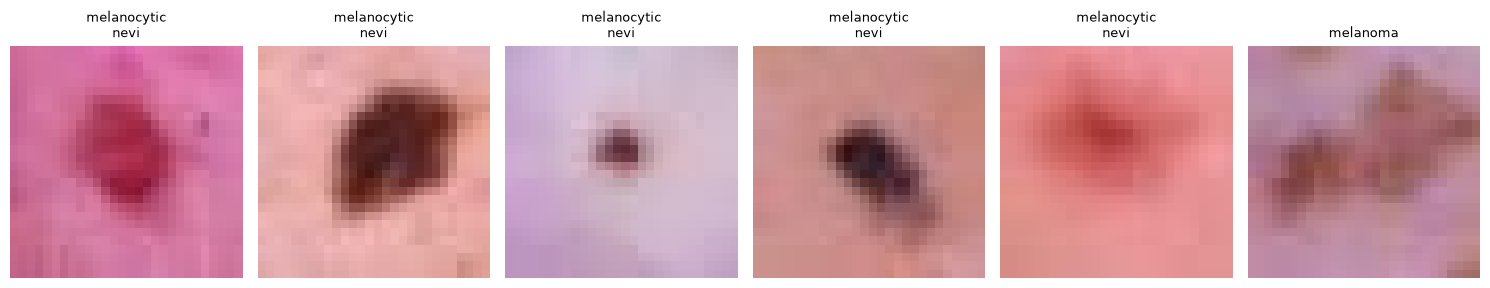

In [5]:
dermamnist_labels = {
    0: "actinic keratoses and intraepithelial carcinoma",
    1: "basal cell carcinoma",
    2: "benign keratosis-like lesions",
    3: "dermatofibroma",
    4: "melanoma",
    5: "melanocytic nevi",
    6: "vascular lesions",
}

x, y = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes.flat):
    img = x[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(img, cmap="gray")
    label = textwrap.fill(dermamnist_labels[y[i].item()], width=12)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Creating noisy DermaMNIST
Adding noise by multiplying each pixel with noise_std (hyperparameter) and clamping to zero/one.

In [6]:
class NoisyDataset(Dataset):

    def __init__(
        self,
        dataset,
        noise_std=0.1,
    ):
        self.dataset = dataset
        self.noise_std = noise_std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        x, y = self.dataset[idx]

        noise = torch.randn_like(x) * self.noise_std

        x_noisy = torch.clamp(
            x + noise,
            0.0,
            1.0,
        )

        return x_noisy, y


noisy_mnist = NoisyDataset(
    test_set,
    noise_std=0.1,
)

noisy_loader = DataLoader(
    noisy_mnist,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

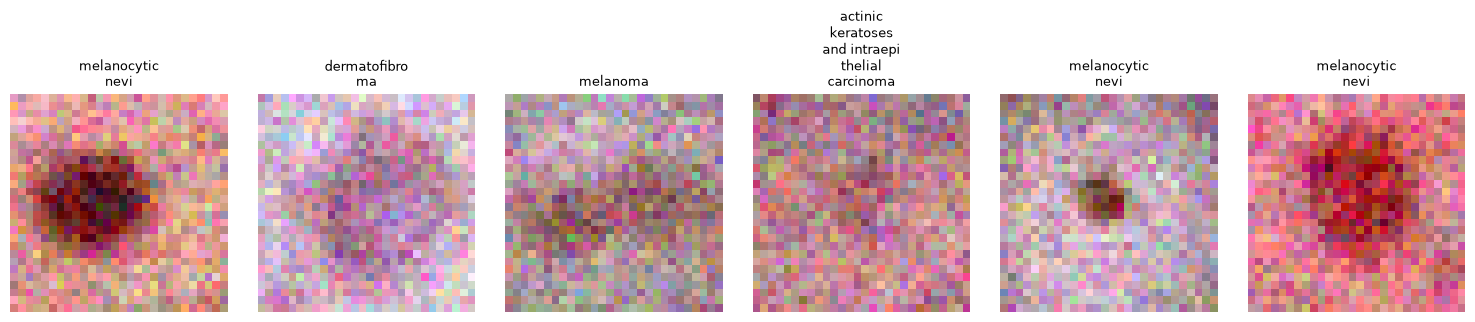

In [7]:
x, y = next(iter(noisy_loader))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes.flat):
    img = x[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(img, cmap="gray")
    label = textwrap.fill(dermamnist_labels[y[i].item()], width=12)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Downloading PathMNIST

In [8]:
path_set = PathMNIST(
    root="./data",
    split="test",
    download=True,
    transform=transform,
)

path_loader = DataLoader(
    path_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

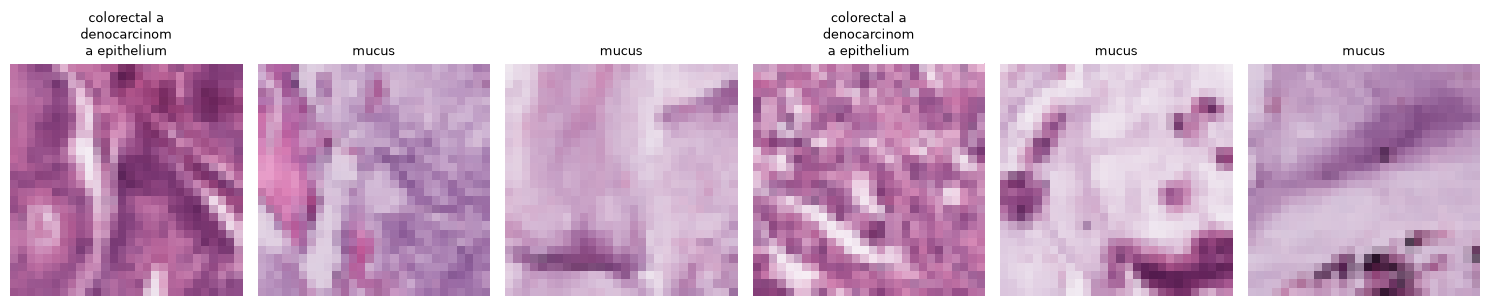

In [9]:
pathmnist_labels = {
    0: "adipose",
    1: "background",
    2: "debris",
    3: "lymphocytes",
    4: "mucus",
    5: "smooth muscle",
    6: "normal colon mucosa",
    7: "cancer-associated stroma",
    8: "colorectal adenocarcinoma epithelium",
}


x, y = next(iter(path_loader))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes.flat):
    img = x[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(img, cmap="gray")
    label = textwrap.fill(pathmnist_labels[y[i].item()], width=12)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. CNN architecture

The model corresponds to the ResNet18 architecture. The embedded features (the input to the fully connected linear layer) are explicitly exposed by calling $\texttt{forward\_features(self, x)}$. This will later be used to compute Mahalanobis distance on.

<img src="resources/ResNetOOD.png" width=1806 height=400 />

In [10]:
class ResNetOOD(nn.Module):

    def __init__(self, num_classes, pretrained=True, in_channels=3):
        super().__init__()

        backbone = resnet18(weights=ResNet18_Weights.DEFAULT if pretrained else None)

        # MedMNIST images are 1 or 3 channels; ResNet expects 3 by default
        if in_channels != 3:
            backbone.conv1 = nn.Conv2d(
                in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
            )

        # Keep everything except the final fc layer
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])  # up to avgpool
        self.feature_dim = backbone.fc.in_features  # 512 for ResNet18

        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward_features(self, x):
        x = self.backbone(x)          # [batch, 512, 1, 1]
        x = torch.flatten(x, 1)       # [batch, 512]
        return x

    def forward(self, x):
        features = self.forward_features(x)
        logits = self.classifier(features)
        return logits

In [11]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA)")
else:
    device = torch.device("cpu")
    print("GPU not available. Using CPU instead.")

Using Apple Silicon GPU (MPS)


## 6a. Training on DermaMNIST

In [12]:
model = ResNetOOD(num_classes=NUM_CLASSES, in_channels=3).to(device)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
epochs = 5

print("Starting training...")
for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).squeeze(1).long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)

        pred = outputs.argmax(1)

        correct += (
            pred == labels
        ).sum().item()

        total += labels.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Accuracy={correct/total:.4f}")

print("Training finished!")

os.makedirs("resources", exist_ok=True)
torch.save(model.state_dict(), "resources/resnet18_weights.pth")


Starting training...
Epoch 1/5 - Loss: 0.8605 - Accuracy=0.6993
Epoch 2/5 - Loss: 0.6830 - Accuracy=0.7528
Epoch 3/5 - Loss: 0.6163 - Accuracy=0.7691
Epoch 4/5 - Loss: 0.5749 - Accuracy=0.7871
Epoch 5/5 - Loss: 0.5412 - Accuracy=0.8005
Training finished!


## 6b. Or Load weights and skip training

In [13]:
model = ResNetOOD(num_classes=NUM_CLASSES, in_channels=3)
model.load_state_dict(torch.load("resources/resnet18_weights.pth", map_location=device))
model.to(device)
print("Model loaded!")

Model loaded!


## 7. Classification accuracy
We will now sanity-check our simple CNN by computing the classification accuracy on ID data, namely the DermaMNIST test set.

In [14]:

@torch.no_grad()
def classification_accuracy(
    model,
    loader,
):

    model.eval()

    correct = 0
    total = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device).squeeze(1).long()

        logits = model(x)

        pred = logits.argmax(1)

        correct += (
            pred == y
        ).sum().item()

        total += y.size(0)

    return correct / total


print(
    "DermaMNIST test accuracy:",
    classification_accuracy(
        model,
        test_loader,
    ),
)

DermaMNIST test accuracy: 0.7506234413965087


# Distance-based OOD scoring: Mahalanobis

The idea of Mahalanobis distance based OOD scoring is to estimate an average representation per class in feature space using the training data (ID) and then computing the Mahalanobis distance from that average representation for a new sample per class. The distance to nearest class centroid is then representative of how similar this new sample is to the training data. Higher distance / score means higher chance of this new sample being OOD.

The scorer follows these steps:
 1. Extract ID features from the penultimate layer using the training set
 2. Per class, estimate mean over features $\hat\mu_c$
 3. Compute residuals by subtract each sample's own true class mean from its feature vector $r_i = f(x_i) - \hat\mu_c$
 4. Estimate shared covariance $\hat\Sigma$ over all classes. $\hat\Sigma = \dfrac{1}{N}\sum_i r_i r_i^T$. Assuming that all classes share the same covariance structure, same shape of spread.
 5. Regularise covariance for numerical stability by adding $\lambda I $
 6. Invert covariance to get precision matrix $\hat\Sigma^{-1}$
 7. The scorer can now be applied to a new dataset. Therefore, extract features of the new input data, e.g. test / OOD data.
 8. Compute Mahalanobis distance to every class $d_c = (f(x) - \hat \mu_c)^T \hat \Sigma_{-1} (f(x)−\hat \mu_c​)$
 9. The final OOD score for each sample is the minimum distance over all classes $score(x)=min_c ​d_c​(x)$


## 1. Extracting features
Extracting features from the explicitly exposed penultimate layer in the simple CNN and saving corresponding labels.

In [15]:
@torch.no_grad()
def extract_features(
    model,
    loader,
):

    model.eval()

    all_features = []
    all_labels = []

    for x, y in loader:

        x = x.to(device)
        y = y.squeeze(1).long()

        features = model.forward_features(x)

        all_features.append(
            features.cpu()
        )

        all_labels.append(y)

    features = torch.cat(
        all_features
    )

    labels = torch.cat(
        all_labels
    )

    return features, labels

In [16]:
train_features, train_labels = extract_features(
    model,
    train_loader,
)

print(
    "\nFeature matrix:",
    train_features.shape,
)


Feature matrix: torch.Size([7007, 512])


## 2. Estimate class means over features

In [17]:
FEATURE_DIM = train_features.shape[1]

class_means = torch.zeros(
    NUM_CLASSES,
    FEATURE_DIM,
)

for c in range(NUM_CLASSES):

    class_features = train_features[
        train_labels.flatten() == c
    ]

    class_means[c] = class_features.mean(
        dim=0
    )


print(
    "Class means:",
    class_means.shape,
)

Class means: torch.Size([7, 512])


## 3. + 4. + 5. Estimating shared covariance
First computing residuals, then covariance. Adding a small term for numeric stability.

In [18]:
residuals = (
    train_features
    - class_means[train_labels]
)

covariance = (
    residuals.T @ residuals
) / len(residuals)

REGULARIZATION = 1e-5

covariance = covariance + (
    REGULARIZATION
    * torch.eye(FEATURE_DIM)
)

## 6. Inverting covariance to get precision

In [19]:
precision = torch.linalg.inv(
    covariance
)


print(
    "Covariance:",
    covariance.shape,
)

print(
    "Precision:",
    precision.shape,
)

Covariance: torch.Size([512, 512])
Precision: torch.Size([512, 512])


## 7. + 8. + 9. Computing Mahalanobis distance on a new dataset

$d_c = (f(x) - \hat \mu_c)^T \hat \Sigma_{-1} (f(x)−\hat \mu_c​)$

In [20]:

@torch.no_grad()
def mahalanobis_scores(
    model,
    loader,
    class_means,
    precision,
):

    model.eval()

    all_scores = []

    for x, _ in loader:

        x = x.to(device)

        features = model.forward_features(x)

        # ----------------------------------------------------
        # features:
        # [batch, feature_dim]
        #
        # class_means:
        # [10, feature_dim]
        #
        # We want:
        #
        # [batch, 10, feature_dim]
        # ----------------------------------------------------

        diff = (
            features[:, None, :]
            - class_means[None, :, :].to(device)
        )

        # ----------------------------------------------------
        # Mahalanobis distance:
        #
        # d = diff^T precision diff
        #
        # Einstein notation:
        #
        # b = batch
        # c = class
        # d/e = feature dimensions
        # ----------------------------------------------------

        distances = torch.einsum(
            "bcd,de,bce->bc",
            diff,
            precision.to(device),
            diff,
        )

        # Closest class
        # smallest distance = most ID-like

        min_distance = distances.min(
            dim=1
        ).values

        all_scores.append(
            min_distance.cpu()
        )

    return torch.cat(all_scores)

## Computing OOD score on ID data

In [21]:
id_mahalanobis = mahalanobis_scores(
    model,
    test_loader,
    class_means,
    precision,
)

## Computing OOD score on OOD data

In [22]:
noisy_mahalanobis = mahalanobis_scores(
    model,
    noisy_loader,
    class_means,
    precision,
)

path_mahalanobis = mahalanobis_scores(
    model,
    path_loader,
    class_means,
    precision,
)

## Visualising OOD scores

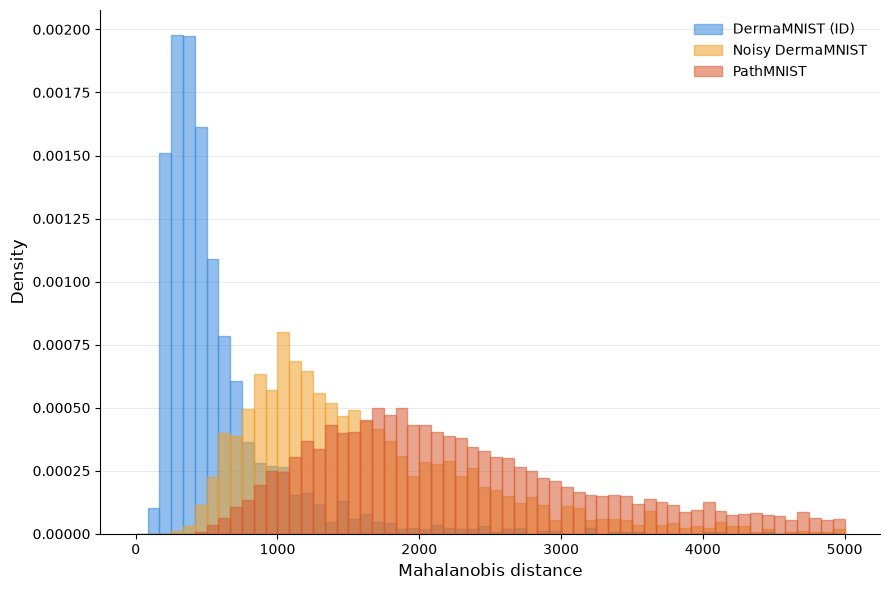

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

bins = np.linspace(0, 5000, 61)

colors = ["#378ADD", "#EF9F27", "#D85A30"]
labels = ["DermaMNIST (ID)", "Noisy DermaMNIST", "PathMNIST"]
data = [id_mahalanobis.numpy(), noisy_mahalanobis.numpy(), path_mahalanobis.numpy()]

for d, c, l in zip(data, colors, labels):
    ax.hist(d, bins=bins, density=True, alpha=0.55, color=c,
             edgecolor=c, linewidth=1.0, label=l)

ax.set_xlabel("Mahalanobis distance", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

# Turn off top and right axis
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Subtle grid, only horizontal
ax.grid(axis="y", alpha=0.3, linewidth=0.6)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

# Classification based OOD scoring: Energy

The energy score is computed using the following formula:
$score(x)=−T⋅log\sum_{i=1}^K ​exp\left(\dfrac{f_i​(x)}{T}\right)$ where $f_i(x)$ are the model's raw logit outputs.
This corresponds exactly to the denominator in the softmax function and is called the partition function in energy-based modelling. The idea of the energy-based scoring is that usual inputs that the model has likely seen before will lead to more confident model outputs, i.e. the logits will have one larger value for one class and all others will be quite small. This pushes $​exp\left(\dfrac{f_i​(x)}{T}\right)$ up leading to lower energy. Unusual, likely OOD, inputs will tend to get more unsure outputs from the model where logits are overall smaller across all classes (no peak). This will decrease $​exp\left(\dfrac{f_i​(x)}{T}\right)$ leading to higher energy.
The temperature $T$ will either sharpen the distribution over logits (for $T < 1$) or flatten it (for $T > 1$).

In [24]:
@torch.no_grad()
def energy_scores(
    model,
    loader,
    temperature=1.0,
):

    model.eval()

    scores = []

    for x, _ in loader:

        x = x.to(device)

        logits = model(x)

        energy = (
            -temperature
            * torch.logsumexp(
                logits / temperature,
                dim=1,
            )
        )

        scores.append(
            energy.cpu()
        )


    return torch.cat(scores)

## Computing OOD score on ID data

In [25]:
# Energy temperature
T = 1.0

id_energy = energy_scores(
    model,
    test_loader,
    T,
)

## Computing OOD score on OOD data

In [26]:
noisy_energy = energy_scores(
    model,
    noisy_loader,
    T,
)

path_energy = energy_scores(
    model,
    path_loader,
    T,
)

## Visualising OOD scores

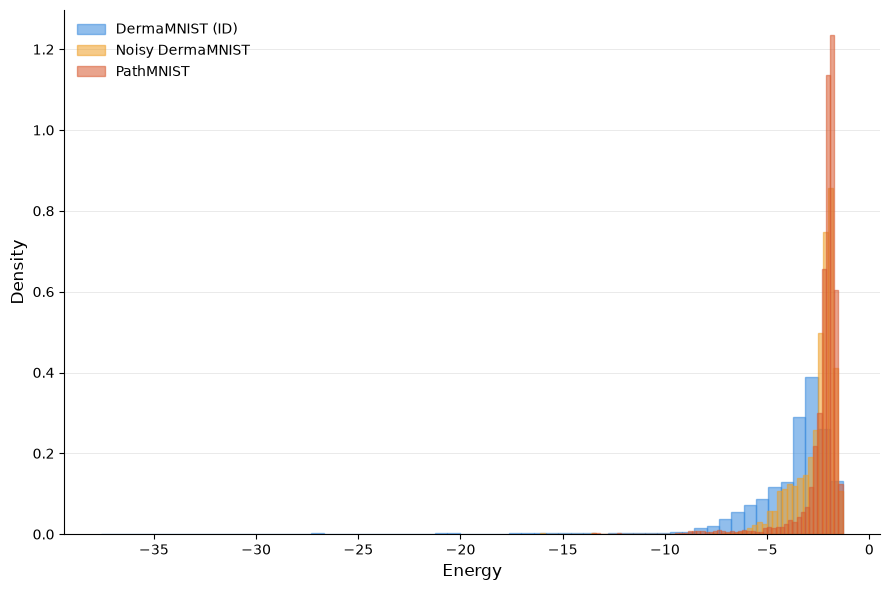

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ["#378ADD", "#EF9F27", "#D85A30"]
labels = ["DermaMNIST (ID)", "Noisy DermaMNIST", "PathMNIST"]
data = [id_energy.numpy(), noisy_energy.numpy(), path_energy.numpy()]

for d, c, l in zip(data, colors, labels):
    ax.hist(d, bins=60, density=True, alpha=0.55, color=c,
             edgecolor=c, linewidth=1.0, label=l)

ax.set_xlabel("Energy", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

# Turn off top and right axis
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Subtle grid, only horizontal
ax.grid(axis="y", alpha=0.3, linewidth=0.6)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

## Applying energy-based OOD scorer to BloodMNIST

In [28]:
blood_set = BloodMNIST(
    root="./data",
    split="test",
    download=True,
    transform=transform,
)

blood_loader = DataLoader(
    blood_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

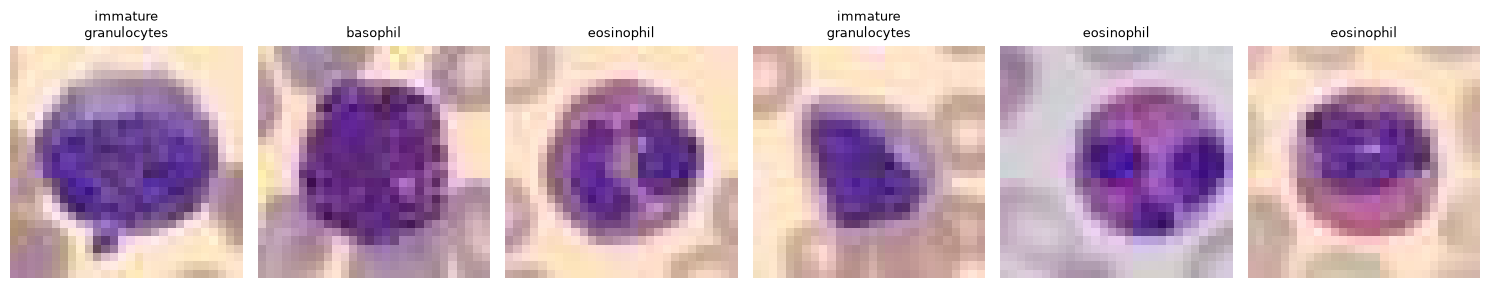

In [29]:
bloodmnist_labels = {
    0: "basophil",
    1: "eosinophil",
    2: "erythroblast",
    3: "immature granulocytes",
    4: "lymphocyte",
    5: "monocyte",
    6: "neutrophil",
    7: "platelet",
}

x, y = next(iter(blood_loader))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i, ax in enumerate(axes.flat):
    img = x[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(img, cmap="gray")
    label = textwrap.fill(bloodmnist_labels[y[i].item()], width=12)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [30]:
blood_energy = energy_scores(
    model,
    blood_loader,
    T,
)

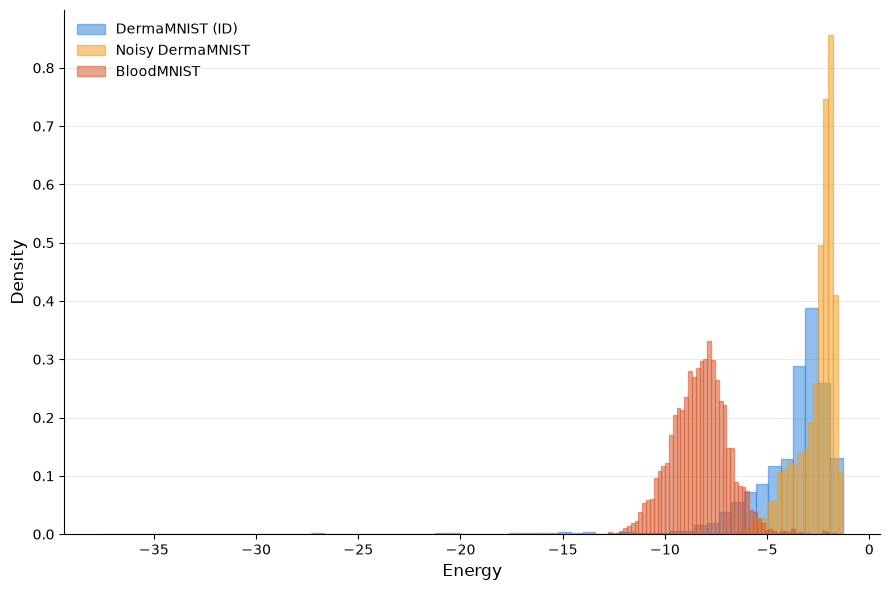

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ["#378ADD", "#EF9F27", "#D85A30"]
labels = ["DermaMNIST (ID)", "Noisy DermaMNIST", "BloodMNIST"]
data = [id_energy.numpy(), noisy_energy.numpy(), blood_energy.numpy()]

for d, c, l in zip(data, colors, labels):
    ax.hist(d, bins=60, density=True, alpha=0.55, color=c,
             edgecolor=c, linewidth=1.0, label=l)

ax.set_xlabel("Energy", fontsize=12)
ax.set_ylabel("Density", fontsize=12)

# Turn off top and right axis
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Subtle grid, only horizontal
ax.grid(axis="y", alpha=0.3, linewidth=0.6)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

As you can see, the BloodMNIST samples display lower energies than even the ID samples. This is because the model is wrongly overconfident in predicting BloodMNIST. One limitation of using output-based methods.

# Tune threshold for OOD detection

Now that we have built two different OOD scoring methods, we can use the synthetically constructed noisy MNIST to tune a treshold for OOD detection.
1. Splitting MNIST and noisy MNIST OOD scores into calibration and test
2. Building OOD/ID labels for calibration split
3. Tuning threshold on calibration split, maximising f1 score
4. Evaluate on held out noisy MNIST

## 1. Splitting scores into calibration and test

In [32]:
def split_scores(
    scores,
    fraction=0.5,
    seed=0,
):

    scores = scores.numpy()

    rng = np.random.default_rng(seed)

    indices = np.arange(len(scores))

    rng.shuffle(indices)

    n_calibration = int(
        len(scores) * fraction
    )

    calibration_idx = indices[:n_calibration]
    test_idx = indices[n_calibration:]

    return (
        scores[calibration_idx],
        scores[test_idx],
    )

# Splitting MNIST scores
id_energy_cal, id_energy_test = split_scores(
    id_energy,
    fraction=0.5,
    seed=0,
)

id_mahal_cal, id_mahal_test = split_scores(
    id_mahalanobis,
    fraction=0.5,
    seed=0,
)

# Splitting noisy MNIST scores
noisy_energy_cal, noisy_energy_test = split_scores(
    noisy_energy,
    fraction=0.5,
    seed=1,
)

noisy_mahal_cal, noisy_mahal_test = split_scores(
    noisy_mahalanobis,
    fraction=0.5,
    seed=1,
)

## 2. Building ID / OOD labels

In [33]:
calibration_labels = np.concatenate([
    np.zeros(len(id_energy_cal)),
    np.ones(len(noisy_energy_cal)),
])

## 3. Tuning thresholds

In [34]:
def tune_threshold(
    id_scores,
    ood_scores,
):

    scores = np.concatenate([
        id_scores,
        ood_scores,
    ])

    labels = np.concatenate([
        np.zeros(len(id_scores)),
        np.ones(len(ood_scores)),
    ])

    # Candidate thresholds are the unique observed scores
    thresholds = np.unique(scores)

    best_threshold = None
    best_f1 = -1.0

    for threshold in thresholds:

        predictions = (
            scores >= threshold
        ).astype(int)

        f1 = f1_score(
            labels,
            predictions,
            zero_division=0,
        )

        if f1 > best_f1:

            best_f1 = f1
            best_threshold = threshold

    return best_threshold, best_f1


# Tune Energy threshold
energy_threshold, energy_cal_f1 = tune_threshold(
    id_energy_cal,
    noisy_energy_cal,
)

# Tune Mahalanobis threshold

mahal_threshold, mahal_cal_f1 = tune_threshold(
    id_mahal_cal,
    noisy_mahal_cal,
)


print("\n")
print("=" * 60)
print("TUNED THRESHOLDS")
print("=" * 60)

print(
    f"Energy threshold:       "
    f"{energy_threshold:.6f}"
)

print(
    f"Energy calibration F1:  "
    f"{energy_cal_f1:.4f}"
)

print()

print(
    f"Mahalanobis threshold:  "
    f"{mahal_threshold:.6f}"
)

print(
    f"Mahalanobis calibration F1: "
    f"{mahal_cal_f1:.4f}"
)



TUNED THRESHOLDS
Energy threshold:       -4.963574
Energy calibration F1:  0.7013

Mahalanobis threshold:  754.266357
Mahalanobis calibration F1: 0.8615


## 4. Evaluate tuned treshold

In [35]:
def evaluate_threshold(
    id_scores,
    ood_scores,
    threshold,
    method_name,
):

    scores = np.concatenate([
        id_scores,
        ood_scores,
    ])

    labels = np.concatenate([
        np.zeros(len(id_scores)),
        np.ones(len(ood_scores)),
    ])

    predictions = (
        scores >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        labels,
        predictions,
    )

    precision = precision_score(
        labels,
        predictions,
        zero_division=0,
    )

    recall = recall_score(
        labels,
        predictions,
        zero_division=0,
    )

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0,
    )

    cm = confusion_matrix(
        labels,
        predictions,
    )

    print("\n")
    print("=" * 60)
    print(method_name)
    print("=" * 60)

    print(
        f"Threshold:  {threshold:.6f}"
    )

    print(
        f"Accuracy:   {accuracy:.4f}"
    )

    print(
        f"Precision:  {precision:.4f}"
    )

    print(
        f"Recall:     {recall:.4f}"
    )

    print(
        f"F1 score:   {f1:.4f}"
    )

    print("\nConfusion matrix:")
    print(
        "             Pred ID   Pred OOD"
    )

    print(
        f"True ID      {cm[0,0]:8d}  "
        f"{cm[0,1]:9d}"
    )

    print(
        f"True OOD     {cm[1,0]:8d}  "
        f"{cm[1,1]:9d}"
    )

    return {
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
    }


# Evaluate Energy on held-out noisy MNIST
energy_results = evaluate_threshold(
    id_energy_test,
    noisy_energy_test,
    energy_threshold,
    "ENERGY — Noisy MNIST OOD",
)


# Evaluate Mahalanobis on held-out noisy MNIST

mahal_results = evaluate_threshold(
    id_mahal_test,
    noisy_mahal_test,
    mahal_threshold,
    "MAHALANOBIS — Noisy MNIST OOD",
)


# Overview

print("\n")
print("=" * 70)
print("FINAL OOD DETECTION COMPARISON")
print("=" * 70)

print(
    f"{'Method':<18}"
    f"{'Threshold':>15}"
    f"{'Accuracy':>15}"
    f"{'F1':>15}"
)

print("-" * 70)

print(
    f"{'Energy':<18}"
    f"{energy_results['threshold']:>15.5f}"
    f"{energy_results['accuracy']:>15.4f}"
    f"{energy_results['f1']:>15.4f}"
)

print(
    f"{'Mahalanobis':<18}"
    f"{mahal_results['threshold']:>15.5f}"
    f"{mahal_results['accuracy']:>15.4f}"
    f"{mahal_results['f1']:>15.4f}"
)



ENERGY — Noisy MNIST OOD
Threshold:  -4.963574
Accuracy:   0.5862
Precision:  0.5490
Recall:     0.9661
F1 score:   0.7001

Confusion matrix:
             Pred ID   Pred OOD
True ID           207        796
True OOD           34        969


MAHALANOBIS — Noisy MNIST OOD
Threshold:  754.266357
Accuracy:   0.8534
Precision:  0.8226
Recall:     0.9013
F1 score:   0.8601

Confusion matrix:
             Pred ID   Pred OOD
True ID           808        195
True OOD           99        904


FINAL OOD DETECTION COMPARISON
Method                  Threshold       Accuracy             F1
----------------------------------------------------------------------
Energy                   -4.96357         0.5862         0.7001
Mahalanobis             754.26636         0.8534         0.8601


## Applying tuned OOD threshold to a realistic OOD dataset
Since PathMNIST is totally out of model scope, the model has no chance to predict correctly, all samples should be OOD based on our learned OOD scores and threshold and none should be retained as ID. However, this is not the case showing the sensitivity of tuned OOD thresholds.

In [36]:
path_energy_is_id = (
    path_energy.numpy()
    < energy_threshold
)

path_mahal_is_id = (
    path_mahalanobis.numpy()
    < mahal_threshold
)

print("\n")
print("=" * 65)
print("Energy: PathMNIST")
print("=" * 65)

print(
    f"Total samples:       {len(path_set)}"
)

print(
    f"Predicted as ID:      "
    f"{path_energy_is_id.sum()}"
)

print(
    f"ID retention rate:    "
    f"{path_energy_is_id.mean():.4f}"
)

print("\n")
print("=" * 65)
print("Mahalanobis: PathMNIST")
print("=" * 65)

print(
    f"Total samples:       {len(path_set)}"
)

print(
    f"Predicted as ID:      "
    f"{path_mahal_is_id.sum()}"
)

print(
    f"ID retention rate:    "
    f"{path_mahal_is_id.mean():.4f}"
)




Energy: PathMNIST
Total samples:       7180
Predicted as ID:      258
ID retention rate:    0.0359


Mahalanobis: PathMNIST
Total samples:       7180
Predicted as ID:      115
ID retention rate:    0.0160
